# Visual Demo

This notebook demonstrates the `PhysComp.visual` module, which visualises data for azimuthal scattering datasets and fitted functions thereof

### Functions covered:
- `visualise.visualise_dataset` — visualises param map from fitting
- `visualise.visualise_params` — visualises param map from fitting
- `visualise_residuals` — visualises param residual map from fitting
- `visualise.test_point` — visualises param map from fitting

#### Needed Imports

In [3]:
### Needed imports for functions
import matplotlib.pyplot as plt
import numpy as np
import PhysComp.fitting as fit

### Importing simulation and fitting function for example data
import PhysComp.sim as sim
import PhysComp.uml as uml

### Importing the visualise function
import PhysComp.visual as vs

## Generating simulated data, decomposing and fitting

In [4]:
simulated_dataset = sim.sim_dataset(30,30,360,100,100, filesave= True,save_path="Test.npy", seed=100) # Simulating data, see Sim notebook
sd = uml.decomp_data("Test.npy","SVD")
params_decomped, errors_decomped = fit.periodic_fit_whole(sd[0], [1,1,1,1,1])
params_raw, errors_raw = fit.periodic_fit_whole(sd[1], [1,1,1,1,1]) 

WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)
WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)
WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)
WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)
WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)
WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)
WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)
WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)
Decomposition info:
  normalize_poissonian_noise

Processing slices: 100%|██████████| 900/900 [00:09<00:00, 93.99it/s]


## Functions

### visualise_dataset

Docstring:

"""

    Allows visualsation of a single degree slice for raw and decomposed data
    
    Parameters
    ----------
    raw: array-like
        Raw parameter dataset, shape (x, y, n_params), second output of fit.periodic_fit_whole
    decomped: array-like
        Decomposed parameter dataset, shape (x, y, n_params), first output of fit.periodic_fit_whole
    degree: int
        Degree slice to show
    colour_map: str
        Chosen colour map for visualisation, defaults to "magma"
    
    Returns
    -------
    Plot of single slice of raw and decomposed data
        
"""

Visualises a dataset alice as an images before and after denoising, for a given degree.

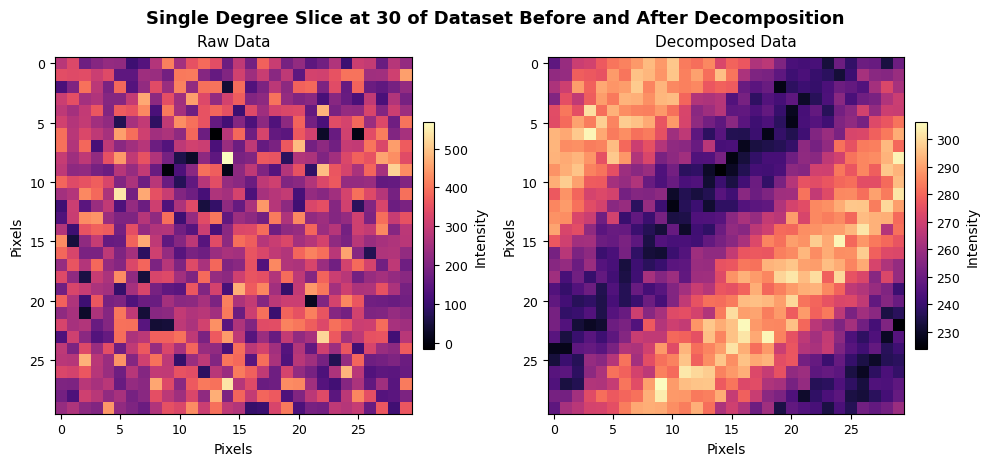

In [5]:
degree = 30 # Chosen degree slice
vs.visualise_dataset(sd[1],sd[0],degree)

### visualise_params

Docstring

"""

    Allows visualsation of fitting parameters map calculated for raw and decomposed data
    
    Parameters
    ----------
    raw: array-like
        Raw parameter dataset, shape (x, y, n_params), second output of fit.periodic_fit_whole
    decomped: array-like
        Decomposed parameter dataset, shape (x, y, n_params), first output of fit.periodic_fit_whole
    num: int
        Number of parameters in fit
    name: str
        Name used in plot in form "raw/decomped {name} {index}", typically "paramater" or "parameter error"
    angle_map,amp_map : str
        Colour map applied to the angle and amplitude parameters respectively
        Defaults to "twilight" and "inferno"
    angle_amp: array-like
        Defines which parameters are angles and amplitude, 1 = amplitude 0 = angle
        Defaults to [0,1,0,1,0], which corresponds to the periodic model used in this package

    Returns
    -------
    Plot of raw and decomposed param maps
        
"""

Shows the raw and decomposed parameter or parameter error maps to assess visual differences.

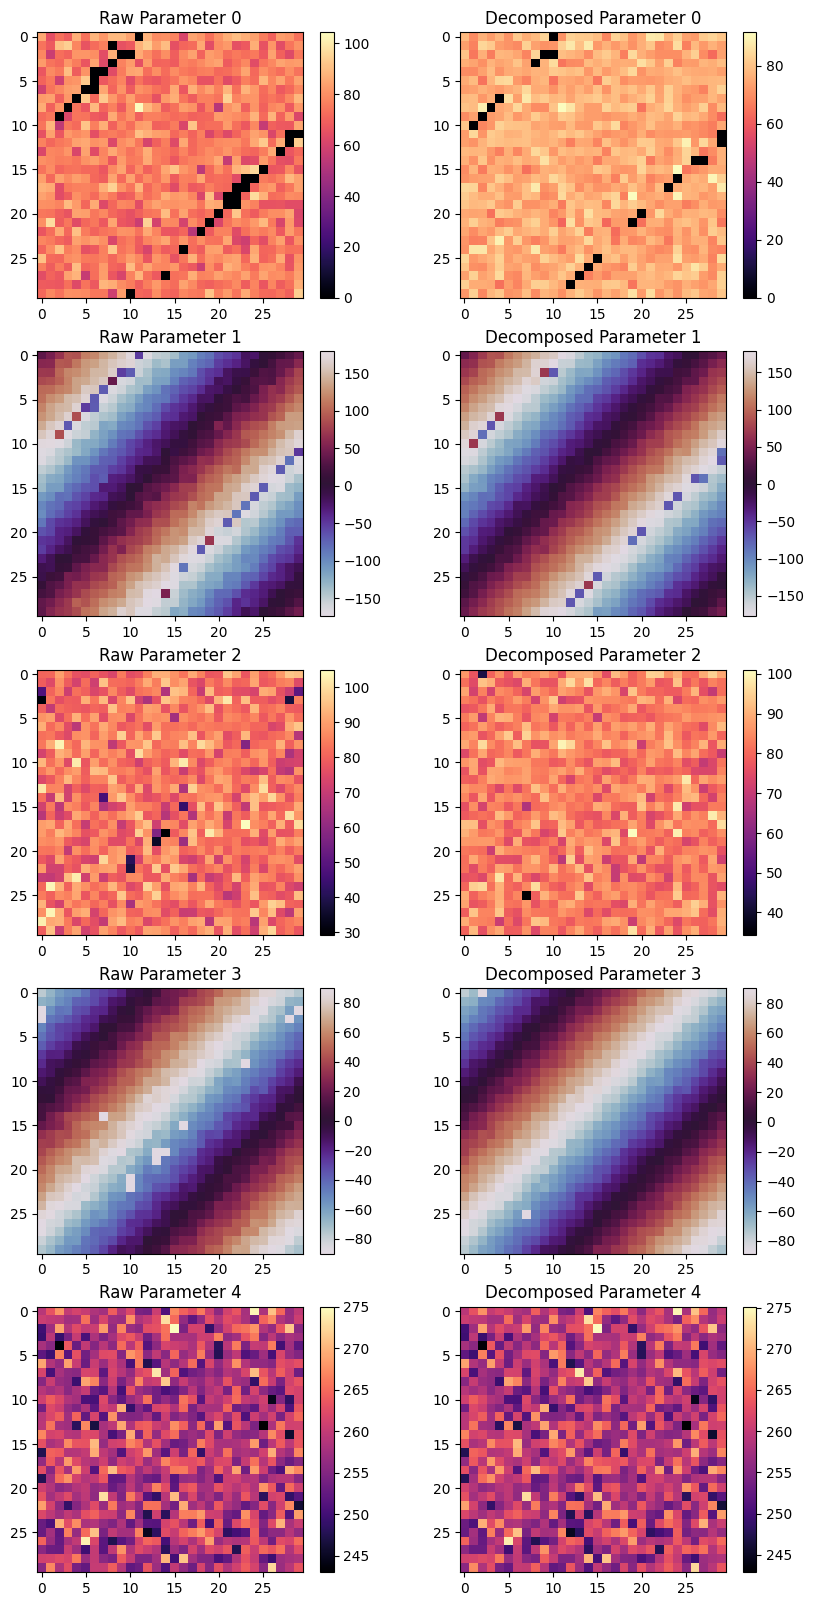

In [7]:
param_num = 5 # Number of parameters in function, 5 for the function fitted in this package
name = "Parameter"
angle_map = "twilight" # Anle map
amp_map = "magma" # Amplitude map
angle_amp = [0,1,0,1,0] # Defines which parameter is amplitude or angle, this says param 0 is amplitude, 1 is angle, 2 is amplitude etc

vs.visualise_params(params_raw,params_decomped,param_num,name,angle_map=angle_map,amp_map=amp_map,angle_amp=angle_amp)

### visualise_residuals

Docstring:

"""

    Allows visualsation of residuals of parameters maps calculated for raw and decomposed data
    
    Parameters
    ----------
    raw: array-like
        Raw parameter dataset, shape (x, y, n_params), second output of fit.periodic_fit_whole
    decomped: array-like
        Decomposed parameter dataset, shape (x, y, n_params), first output of fit.periodic_fit_whole
    num: int
        Number of parameters in fit
    Returns
    -------
    Plot of raw and decomposed param maps residuals
"""

Shows the raw and decomposed parameter maps or actual data to assess visual differences.

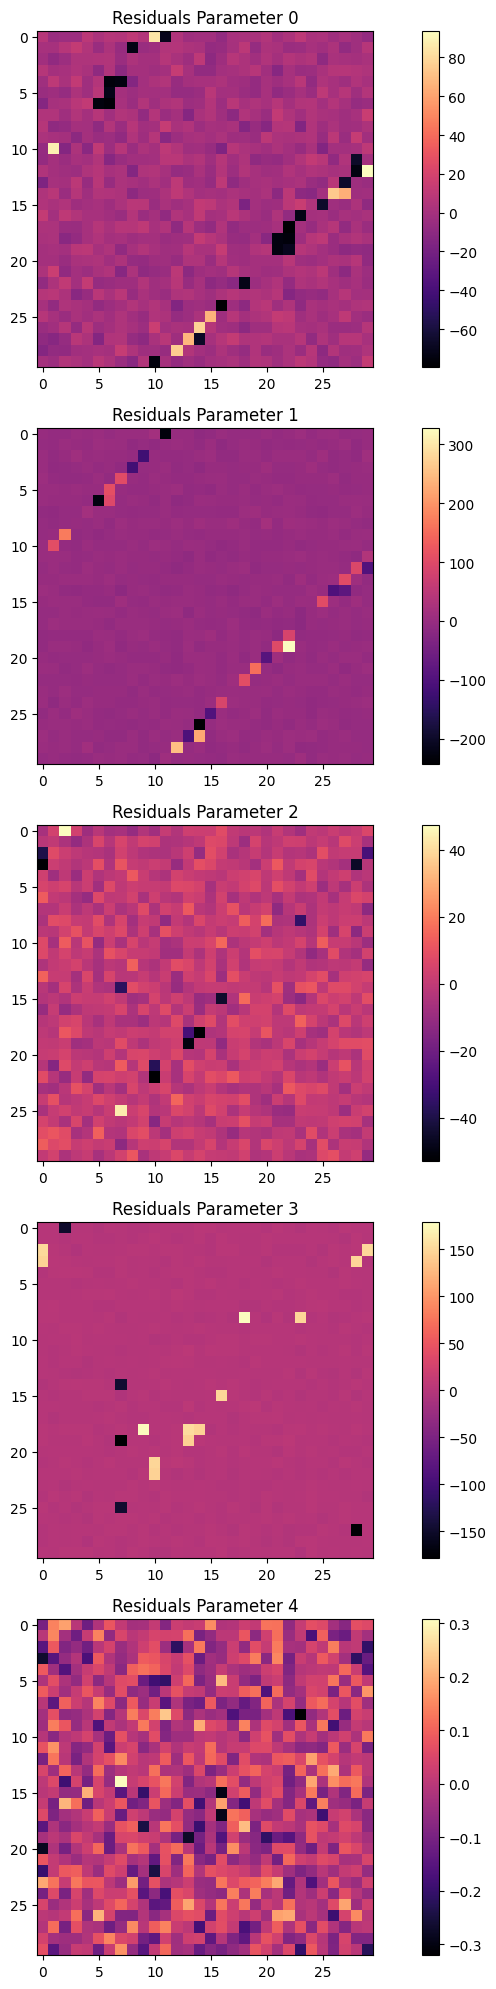

<Figure size 640x480 with 0 Axes>

In [9]:
vs.visualise_residuals(params_raw,params_decomped,5)

### test_point

Docstring:

"""

    Visualise the raw and decomposed data and the corresponding fits for a given pixel.

    Parameters
    ----------
    raw: array-like
        Raw dataset, shape (x, y, degrees)
    decomped: array-like
        Decomposed dataset, shape (x, y, degrees)
    raw_params: array-like
        Raw params dataset, shape (x, y, n_params)
    decomp_params: array-like
        Decomposed params dataset, shape (x, y, n_params)
    test_point: array-like,int
        Chosen pixel to visualise, form [x,y]
    degrees: int
        Number of degrees in pixel signal

    Returns
    -------
    Plot of raw and decomposed fits and data
        
"""

Shows the raw and decomposed functions and data from a single pixel test point to assess visual differences.

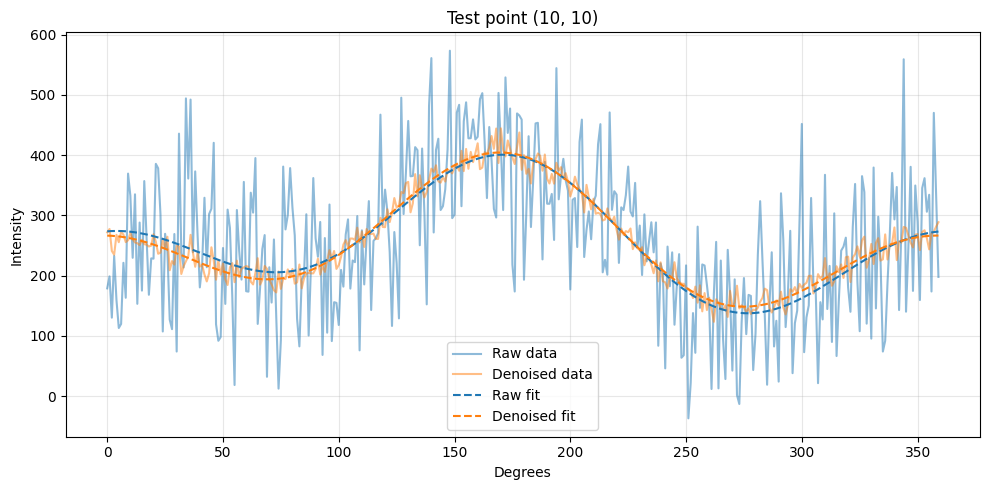

In [11]:
test_point = [10,10] # Chosen pixel to visualise
degrees = 360 # Degrees in signal

vs.test_point(sd[1],sd[0],params_raw,params_decomped,test_point,degrees)